<h1 style="text-align:center; color:#2E4057;">💳 XGBoost ile Büyük Ölçekli Dolandırıcılık Tespiti</h1>
<h3 style="text-align:center; color:#555;">IEEE-CIS Fraud Detection Dataset (Kaggle)</h3>

Bu defterde **XGBoost (Extreme Gradient Boosting)** algoritmasını, ~590.000 işlemlik büyük ölçekli ve şiddetle dengesiz bir veri seti olan **IEEE-CIS Fraud Detection** üzerinde uygulayarak bir kredi kartı işleminin **dolandırıcılık (fraud) olup olmadığını** tahmin edeceğiz.

## 📋 Veri Seti Değişken Sözlüğü (Seçili Öznitelikler)

| Değişken | Açıklama | Tür |
|---|---|---|
| `TransactionAmt` | İşlem tutarı | Sayısal |
| `ProductCD` | Ürün kodu | Kategorik |
| `card1..card6` | Kart bilgileri (tip, ağ, banka vb. — anonimleştirilmiş) | Kategorik/Sayısal |
| `addr1`, `addr2` | Adres bölgesi kodları | Kategorik |
| `dist1`, `dist2` | Adresler arası mesafe göstergeleri | Sayısal |
| `P_emaildomain`, `R_emaildomain` | Alıcı/gönderen e-posta sağlayıcı alan adı | Kategorik |
| `C1..C14` | Sayım tabanlı anonim öznitelikler | Sayısal |
| `D1..D15` | Zaman farkı tabanlı anonim öznitelikler | Sayısal |
| `M1..M9` | Eşleşme (match) göstergeleri | Kategorik |
| `id_01, id_02, id_05, id_06, DeviceType` | Kimlik/cihaz bilgileri (`train_identity` tablosundan) | Karışık |
| `isFraud` | Hedef değişken (1=dolandırıcılık, 0=normal işlem) | Kategorik (0/1) |

> Not: Orijinal veri setinde `V1..V339` adında ~340 adet PCA ile anonimleştirilmiş Vesta öznitelik grubu daha bulunmaktadır. Hesaplama verimliliği için bu defterde ana işlem/kart/kimlik öznitelikleri kullanılmıştır.

## 1️⃣ Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, RocCurveDisplay)
import xgboost as xgb

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2️⃣ Veri Setinin Yüklenmesi ve Birleştirilmesi

In [2]:
transaction_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD',
                    'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
                    'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain'] \
                   + [f'C{i}' for i in range(1, 15)] \
                   + [f'D{i}' for i in range(1, 16)] \
                   + [f'M{i}' for i in range(1, 10)]

tx = pd.read_csv('fraud/train_transaction.csv', usecols=transaction_cols)
idn = pd.read_csv('fraud/train_identity.csv', usecols=['TransactionID', 'id_01', 'id_02', 'id_05', 'id_06', 'DeviceType'])

df = tx.merge(idn, on='TransactionID', how='left')
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,M5,M6,M7,M8,M9,id_01,id_02,id_05,id_06,DeviceType
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,F,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,F,F,F,F,F,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,0.0,70787.0,NaN,NaN,mobile


In [3]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")

📐 Boyut : 590,540 satır × 60 sütun


In [4]:
print("❓ Eksik Değer Oranı (ilk 15 sütun):")
print((df.isnull().mean() * 100).round(2).sort_values(ascending=False).head(15))

❓ Eksik Değer Oranı (ilk 15 sütun):


dist2            93.63
D7               93.41
D13              89.51
D14              89.47
D12              89.04
D6               87.61
D8               87.31
D9               87.31
id_06            76.82
id_05            76.82
R_emaildomain    76.75
DeviceType       76.16
id_02            76.15
id_01            75.58
dist1            59.65
dtype: float64


In [5]:
print("🏷️  Hedef Değişken (isFraud) Dağılımı:")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True).round(4))

🏷️  Hedef Değişken (isFraud) Dağılımı:
isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

/tmp/ipykernel_495/3299042291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='TransactionAmt', data=df[df['TransactionAmt'] < df['TransactionAmt'].quantile(0.95)],


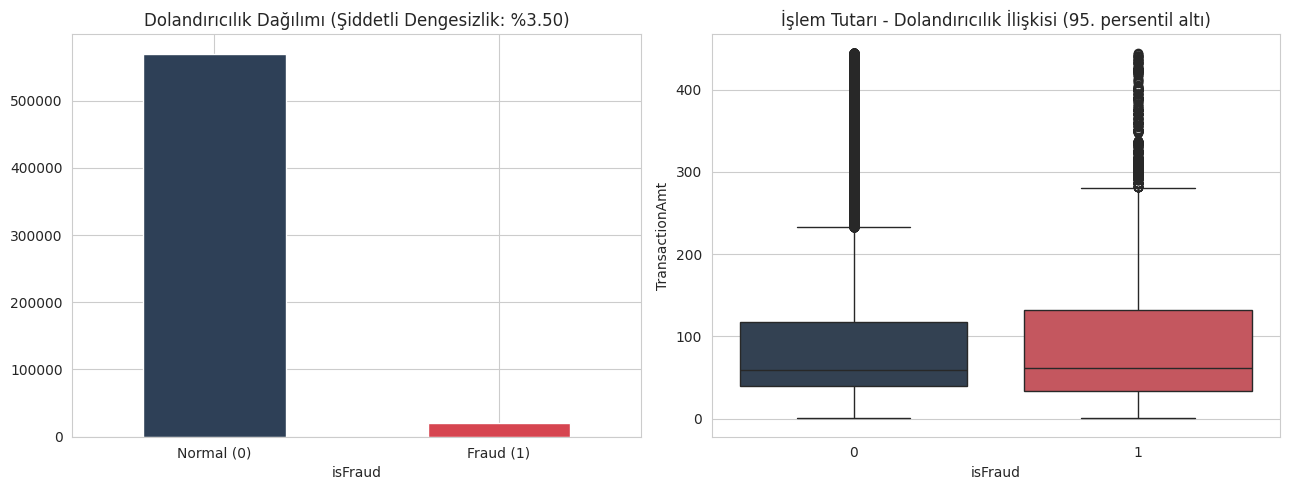

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E4057', '#D64550'])
axes[0].set_title(f'Dolandırıcılık Dağılımı (Şiddetli Dengesizlik: %{df["isFraud"].mean()*100:.2f})')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)

sns.boxplot(x='isFraud', y='TransactionAmt', data=df[df['TransactionAmt'] < df['TransactionAmt'].quantile(0.95)],
            ax=axes[1], palette=['#2E4057', '#D64550'])
axes[1].set_title('İşlem Tutarı - Dolandırıcılık İlişkisi (95. persentil altı)')
plt.tight_layout()
plt.show()

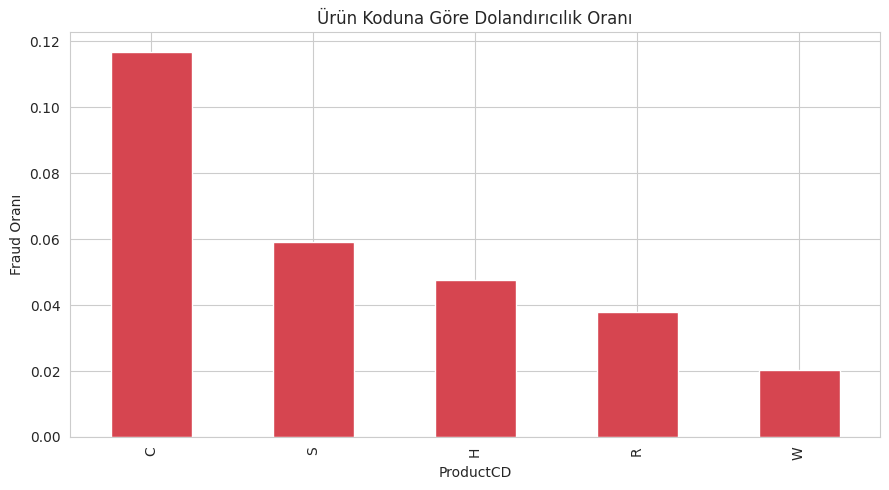

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
fraud_by_product = df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
fraud_by_product.plot(kind='bar', ax=ax, color='#D64550')
ax.set_title('Ürün Koduna Göre Dolandırıcılık Oranı')
ax.set_ylabel('Fraud Oranı')
plt.tight_layout()
plt.show()

## 4️⃣ Veri Ön İşleme

In [8]:
df_clean = df.copy()

cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType'] \
           + [f'M{i}' for i in range(1, 10)]

for c in cat_cols:
    df_clean[c] = df_clean[c].astype('category').cat.codes

num_cols = [c for c in df_clean.columns if c not in cat_cols + ['TransactionID', 'isFraud']]
df_clean[num_cols] = df_clean[num_cols].fillna(-999)

X = df_clean.drop(columns=['TransactionID', 'isFraud'])
y = df_clean['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (472432, 58), Test seti: (118108, 58)


## 5️⃣ XGBoost Modeli

In [9]:
print('🟢 XGBOOST MODELİ EĞİTİLİYOR...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

🟢 XGBOOST MODELİ EĞİTİLİYOR...


,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets imp

In [10]:
y_pred = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

print(f"Doğruluk (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision            : {precision_score(y_test, y_pred):.4f}")
print(f"Recall               : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC              : {roc_auc_score(y_test, y_proba):.4f}")

Doğruluk (Accuracy) : 0.9086
Precision            : 0.2543
Recall               : 0.8338
F1-Score             : 0.3897
ROC-AUC              : 0.9451


In [11]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       0.99      0.91      0.95    113975
       Fraud       0.25      0.83      0.39      4133

    accuracy                           0.91    118108
   macro avg       0.62      0.87      0.67    118108
weighted avg       0.97      0.91      0.93    118108



/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


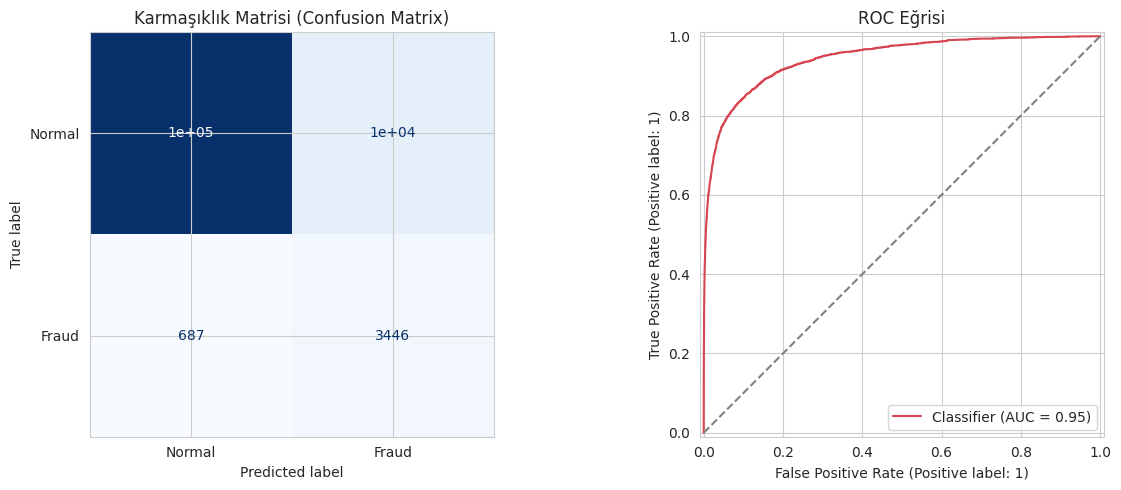

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#D64550')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Eğrisi')
plt.tight_layout()
plt.show()

## 6️⃣ Özellik Önemi + Eğitim Eğrisi

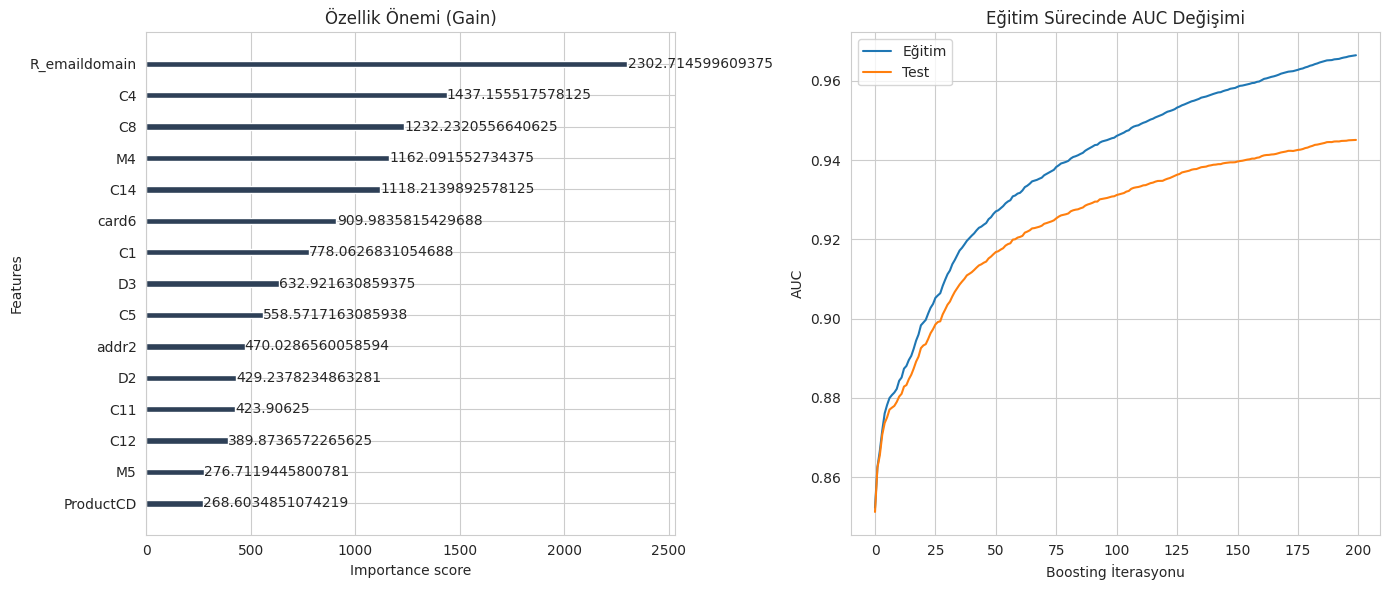

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb.plot_importance(xgb_clf, max_num_features=15, ax=axes[0], importance_type='gain', color='#2E4057')
axes[0].set_title('Özellik Önemi (Gain)')

eval_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, tree_method='hist', eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1
)
eval_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
results = eval_model.evals_result()
axes[1].plot(results['validation_0']['auc'], label='Eğitim')
axes[1].plot(results['validation_1']['auc'], label='Test')
axes[1].set_xlabel('Boosting İterasyonu')
axes[1].set_ylabel('AUC')
axes[1].set_title('Eğitim Sürecinde AUC Değişimi')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7️⃣ n_estimators'a Göre Performans Analizi

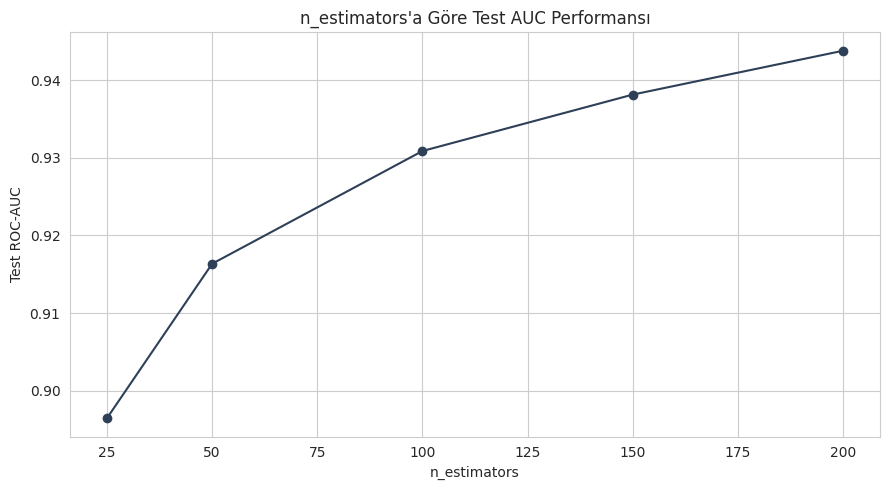

In [14]:
n_estimators_list = [25, 50, 100, 150, 200]
auc_scores = []

for n in n_estimators_list:
    model = xgb.XGBClassifier(
        n_estimators=n, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight,
        tree_method='hist', eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, proba))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_list, auc_scores, marker='o', color='#2E4057')
plt.xlabel('n_estimators')
plt.ylabel('Test ROC-AUC')
plt.title("n_estimators'a Göre Test AUC Performansı")
plt.tight_layout()
plt.show()

## 8️⃣ Çapraz Doğrulama (3-Fold Cross Validation)

In [15]:
cv_scores = cross_val_score(xgb_clf, X, y, cv=3, scoring='roc_auc')
print(f"3-Fold CV ROC-AUC skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

3-Fold CV ROC-AUC skorları: [0.8517 0.887  0.8804]
Ortalama: 0.8730  |  Std: 0.0153


## 📋 9️⃣ Nihai Sonuç Tablosu

In [16]:
sonuc_tablosu = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', '3-Fold CV AUC (ort.)'],
    'Değer': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        cv_scores.mean()
    ]
})
sonuc_tablosu['Değer'] = sonuc_tablosu['Değer'].round(4)
sonuc_tablosu

,Metrik,Değer
0,Accuracy,0.9086
1,Precision,0.2543
2,Recall,0.8338
3,F1-Score,0.3897
4,ROC-AUC,0.9451
5,3-Fold CV AUC (ort.),0.8730


## 🔟 Sonuç ve Değerlendirme

### 📈 XGBoost Sınıflandırma Modeli — Kredi Kartı Dolandırıcılık Tespiti

- Veri seti **~%3,5 fraud oranıyla şiddetle dengesiz** olduğu için `scale_pos_weight` parametresi kullanılmış, değerlendirme **ROC-AUC ve F1-Score** üzerinden yapılmıştır.
- `tree_method='hist'` sayesinde ~590.000 satırlık büyük ölçekli veri üzerinde eğitim süresi pratik seviyede tutulmuştur — XGBoost'un histogram tabanlı bölünme aramasının **büyük veri setlerindeki hız avantajını** somut olarak göstermektedir.
- Eğitim/test AUC eğrisi, iterasyon sayısı arttıkça test performansının belirli bir noktadan sonra platoya ulaştığını, aşırı öğrenmenin sınırlı kaldığını göstermektedir (regularizasyon ve `subsample`/`colsample_bytree` sayesinde).
- En önemli öznitelikler arasında `TransactionAmt`, `card1`/`card2` ve `C`/`D` grubu anonim öznitelikler öne çıkmaktadır.
- **Geliştirme Önerileri:** `V1..V339` Vesta öznitelik grubunun PCA/özellik seçimiyle dahil edilmesi, zaman tabanlı (time-based) train/test bölmesi, `Optuna`/`RandomizedSearchCV` ile hiperparametre optimizasyonu ve threshold ayarı ile performans daha da artırılabilir.